<a href="https://colab.research.google.com/github/miray7yuce/quadcopter-rl-copilot/blob/main/notebooks/quadcopter_rl.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [135]:
!pip install -q stable-baselines3 gymnasium
!pip uninstall -y -q jsbsim
!pip install -q jsbsim==1.2.4
!pip install -q pyyaml
!pip install -q optuna

import jsbsim
print(jsbsim.__version__)

1.2.4


In [136]:
from google.colab import userdata
import os

USER  = "miray7yuce"
REPO  = "quadcopter-rl-copilot"
TOKEN = userdata.get('GH_TOKEN')

!git config --global user.email "miray7yuce@gmail.com"
!git config --global user.name "miray7yuce"

os.environ['REMOTE'] = f"https://{TOKEN}@github.com/{USER}/{REPO}.git"
!rm -rf /content/repo
!git clone -q $REMOTE /content/repo
!ls -a /content/repo

.   configs  .gitignore  README.md	   runs
..  .git     notebooks	 requirements.txt  src


In [156]:
import os
os.chdir('/content')
print(os.getcwd())

/content


In [155]:
!pip freeze | grep -iE "^(jsbsim|stable-baselines3|gymnasium|torch|numpy)=" > /content/repo/requirements.txt
!cat /content/repo/requirements.txt

gymnasium==1.3.0
jsbsim==1.2.4
numpy==2.1.3


In [154]:
import os, sys

BASE = "/content/repo"

for d in ["src/drone_rl/envs", "src/drone_rl/utils", "configs"]:
    os.makedirs(f"{BASE}/{d}", exist_ok=True)

for p in ["src/drone_rl", "src/drone_rl/envs", "src/drone_rl/utils"]:
    open(f"{BASE}/{p}/__init__.py", "a").close()

with open(f"{BASE}/.gitignore", "w") as f:
    f.write("__pycache__/\n*.zip\n*.pkl\nlogs/\nruns/\n.ipynb_checkpoints/\n")

sys.path.insert(0, f"{BASE}/src")

!find /content/repo -not -path '*/.git/*' -type f | sort

os.environ['PYTHONPATH'] = f"{BASE}/src"

/content/repo/configs/ppo_hover.yaml
/content/repo/.gitignore
/content/repo/notebooks/quadcopter_rl.ipynb
/content/repo/README.md
/content/repo/requirements.txt
/content/repo/runs/hover_v1/model.zip
/content/repo/runs/hover_v1/vecnormalize.pkl
/content/repo/src/drone_rl/acmi_writer.py
/content/repo/src/drone_rl/config.py
/content/repo/src/drone_rl/env_factory.py
/content/repo/src/drone_rl/envs/f450_env.py
/content/repo/src/drone_rl/envs/__init__.py
/content/repo/src/drone_rl/evaluate.py
/content/repo/src/drone_rl/__init__.py
/content/repo/src/drone_rl/train.py
/content/repo/src/drone_rl/tune.py
/content/repo/src/drone_rl/utils/__init__.py
/content/repo/src/drone_rl/utils/units.py


In [153]:
%%writefile /content/repo/src/drone_rl/utils/units.py
"""Birim donusumleri. JSBSim emperyal birim kullanir."""

FT2M = 0.3048
M2FT = 1.0 / FT2M

def ft_to_m(x):
    return x * FT2M

def m_to_ft(x):
    return x * M2FT

Overwriting /content/repo/src/drone_rl/utils/units.py


In [152]:
%%writefile /content/repo/src/drone_rl/envs/f450_env.py
"""F450 quadcopter icin hover gorevi ortami."""

import numpy as np
import gymnasium as gym
from gymnasium import spaces
import jsbsim


class F450HoverEnv(gym.Env):
    """JSBSim F450 modeli uzerinde sabit irtifada durma (hover) gorevi.

    Tum sayisal ayarlar (hedef irtifa, hover gazi, odul agirliklari,
    crash esikleri) constructor parametreleridir ve
    configs/ppo_hover.yaml + drone_rl.config.load_config ile
    doldurulabilir. Parametre verilmezse, refactor-oncesi kodda
    hardcoded olan degerlerle AYNI varsayilanlar kullanilir.

    step() her adimda info sozlugunde ham telemetri dondurur. Bunun
    sebebi: VecEnv'ler episode bittiginde alt ortami OTOMATIK reset
    eder, dolayisiyla disaridan `env.fdm[...]` okuyan kod son adimda
    zaten resetlenmis (yeni episode'un IC'leri) degerleri gorur.
    info ise reset'ten etkilenmez, dogru kareyi tasir.
    """

    metadata = {"render_modes": []}

    def __init__(
        self,
        target_altitude_ft=30.0,
        episode_seconds=20.0,
        physics_hz=240,
        control_hz=20,
        hover_throttle=0.420,
        throttle_range=0.25,
        reward_alt_weight=0.10,
        reward_tilt_weight=0.50,
        reward_spin_weight=0.10,
        reward_jerk_weight=0.05,
        crash_penalty=50.0,
        crash_min_alt_ft=1.0,
        crash_max_alt_offset_ft=60.0,
        crash_max_tilt_rad=1.0,
    ):
        super().__init__()

        physics_hz = int(physics_hz)
        control_hz = int(control_hz)
        if physics_hz <= 0 or control_hz <= 0:
            raise ValueError("physics_hz ve control_hz pozitif olmali")
        if physics_hz % control_hz != 0:
            # Aksi halde substeps asagi yuvarlanir, gercek kontrol frekansi
            # istenenden farkli olur ama max_steps hala istenen degere gore
            # hesaplanir -> episode suresi sessizce yanlis olur.
            raise ValueError(
                f"physics_hz ({physics_hz}) control_hz'e ({control_hz}) tam "
                "bolunmeli. Or: 240/20=12 OK, 240/50 HATALI."
            )

        self.action_space = spaces.Box(-1.0, 1.0, shape=(4,), dtype=np.float32)
        self.observation_space = spaces.Box(-np.inf, np.inf, shape=(13,), dtype=np.float32)

        self.target_altitude = target_altitude_ft
        self.physics_hz = physics_hz
        self.physics_dt = 1.0 / physics_hz
        self.control_hz = control_hz
        self.substeps = physics_hz // control_hz
        self.max_steps = int(episode_seconds * control_hz)

        self.hover_throttle = hover_throttle
        self.throttle_range = throttle_range

        self.reward_alt_weight = reward_alt_weight
        self.reward_tilt_weight = reward_tilt_weight
        self.reward_spin_weight = reward_spin_weight
        self.reward_jerk_weight = reward_jerk_weight
        self.crash_penalty = crash_penalty
        self.crash_min_alt_ft = crash_min_alt_ft
        self.crash_max_alt_offset_ft = crash_max_alt_offset_ft
        self.crash_max_tilt_rad = crash_max_tilt_rad

        self.fdm = jsbsim.FGFDMExec(None)
        self.fdm.set_debug_level(0)
        if not self.fdm.load_model("F450"):
            raise RuntimeError("F450 modeli yuklenemedi")
        self.fdm.set_dt(self.physics_dt)

        self.step_count = 0
        self.prev_action = np.zeros(4, dtype=np.float32)

    @property
    def control_dt(self):
        """Bir 'step()' cagrisinin temsil ettigi sure (saniye).
        evaluate.py gibi diger kodun control_hz'i elle tekrar
        hesaplamasina gerek kalmaz, dogrudan buradan okur."""
        return self.substeps * self.physics_dt

    def _apply_initial_conditions(self):
        h0 = self.target_altitude + self.np_random.uniform(-3.0, 3.0)
        self.fdm["ic/h-agl-ft"] = h0
        self.fdm["ic/u-fps"] = self.np_random.uniform(-1.0, 1.0)
        self.fdm["ic/v-fps"] = self.np_random.uniform(-1.0, 1.0)
        self.fdm["ic/w-fps"] = self.np_random.uniform(-1.0, 1.0)
        self.fdm["ic/phi-rad"] = self.np_random.uniform(-0.05, 0.05)
        self.fdm["ic/theta-rad"] = self.np_random.uniform(-0.05, 0.05)
        self.fdm["ic/psi-true-rad"] = 0.0

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)

        self._apply_initial_conditions()
        self.fdm.run_ic()

        for i in range(4):
            self.fdm[f"propulsion/engine[{i}]/set-running"] = 1
        self.fdm["fcs/ScasEngage"] = 0

        for i in range(4):
            self.fdm[f"fcs/throttle-cmd-norm[{i}]"] = self.hover_throttle

        self.step_count = 0
        self.prev_action = np.zeros(4, dtype=np.float32)

        return self._get_obs(), {}

    def _get_obs(self):
        f = self.fdm
        alt_err = (f["position/h-agl-ft"] - self.target_altitude) / 10.0
        hdot = f["velocities/h-dot-fps"] / 10.0
        u = f["velocities/u-fps"] / 10.0
        v = f["velocities/v-fps"] / 10.0
        roll = f["attitude/phi-rad"]
        pitch = f["attitude/theta-rad"]
        p = f["velocities/p-rad_sec"] / 5.0
        q = f["velocities/q-rad_sec"] / 5.0
        r = f["velocities/r-rad_sec"] / 5.0

        return np.array(
            [alt_err, hdot, u, v, roll, pitch, p, q, r, *self.prev_action],
            dtype=np.float32,
        )

    def _get_telemetry(self, crashed):
        """Disaridaki kayit/gorsellestirme kodu icin ham durum.
        VecEnv auto-reset'inden ONCE, step() icinde toplanir."""
        f = self.fdm
        alt_agl_ft = float(f["position/h-agl-ft"])
        return {
            "alt_ft": alt_agl_ft,
            "alt_sl_ft": float(f["position/h-sl-ft"]),      # ACMI icin MSL irtifa
            "alt_err_ft": abs(alt_agl_ft - self.target_altitude),
            "lat_deg": float(f["position/lat-geod-deg"]),
            "lon_deg": float(f["position/long-gc-deg"]),
            "roll_rad": float(f["attitude/phi-rad"]),
            "pitch_rad": float(f["attitude/theta-rad"]),
            "yaw_rad": float(f["attitude/psi-rad"]),
            "crashed": bool(crashed),
        }

    def _is_crashed(self):
        alt = self.fdm["position/h-agl-ft"]
        return (
            alt < self.crash_min_alt_ft
            or alt > self.target_altitude + self.crash_max_alt_offset_ft
            or abs(self.fdm["attitude/phi-rad"]) > self.crash_max_tilt_rad
            or abs(self.fdm["attitude/theta-rad"]) > self.crash_max_tilt_rad
        )

    def step(self, action):
        action = np.asarray(action, dtype=np.float32).reshape(4)

        throttles = np.clip(
            self.hover_throttle + action * self.throttle_range, 0.0, 1.0
        )

        for _ in range(self.substeps):
            for i in range(4):
                self.fdm[f"fcs/throttle-cmd-norm[{i}]"] = float(throttles[i])
            self.fdm.run()

        self.step_count += 1
        obs = self._get_obs()

        alt_err_ft = abs(self.fdm["position/h-agl-ft"] - self.target_altitude)
        tilt = abs(self.fdm["attitude/phi-rad"]) + abs(self.fdm["attitude/theta-rad"])
        spin = abs(self.fdm["velocities/p-rad_sec"]) + abs(self.fdm["velocities/q-rad_sec"])
        jerk = float(np.sum(np.abs(action - self.prev_action)))

        reward = (
            1.0
            - self.reward_alt_weight * alt_err_ft
            - self.reward_tilt_weight * tilt
            - self.reward_spin_weight * spin
            - self.reward_jerk_weight * jerk
        )

        crashed = self._is_crashed()
        if crashed:
            reward -= self.crash_penalty

        info = self._get_telemetry(crashed)

        self.prev_action = action.copy()

        terminated = bool(crashed)
        truncated = bool(self.step_count >= self.max_steps)

        return obs, float(reward), terminated, truncated, info

Overwriting /content/repo/src/drone_rl/envs/f450_env.py


In [151]:
%%writefile /content/repo/src/drone_rl/train.py
"""F450 hover gorevi icin PPO veya SAC egitimi + EvalCallback.

--algo ppo (varsayilan) veya --algo sac ile hangi algoritmanin
kullanilacagi secilir. Ortam, callback'ler ve kayit mantigi her iki
algoritma icin de ayni; sadece model olusturma satiri degisir.
"""

import argparse
from pathlib import Path
import numpy as np
from drone_rl.acmi_writer import ACMIWriter
from drone_rl.utils.units import ft_to_m

from stable_baselines3 import PPO, SAC
from stable_baselines3.common.callbacks import BaseCallback, CheckpointCallback, EvalCallback

from drone_rl.config import load_config
from drone_rl.env_factory import make_training_vec_env


class SaveVecNormalizeCallback(BaseCallback):
    """EvalCallback her yeni en iyi modeli bulduğunda, o anki
    VecNormalize istatistiklerini de best_model klasörüne kaydeder.
    Bunsuz best_model.zip yüklendiğinde yanlış olceklenmis
    gozlemlerle calisir (best_model aninda kaydedilen istatistikler,
    egitim sonunda kaydedilenle ayni olmayabilir)."""

    def __init__(self, save_path: Path):
        super().__init__()
        self.save_path = Path(save_path)

    def _on_step(self) -> bool:
        vec_normalize = self.model.get_vec_normalize_env()
        if vec_normalize is not None:
            self.save_path.mkdir(parents=True, exist_ok=True)
            vec_normalize.save(str(self.save_path / "vecnormalize_best.pkl"))
        return True

class ACMISnapshotCallback(BaseCallback):
    """EvalCallback ile ayni periyotta (eval_freq), o anki politikayla
    TEK bir episode calistirip ayri bir .acmi dosyasi olarak kaydeder.
    Boylece egitim ilerledikce ucus davranisinin nasil degistigi
    Tacview'de snapshot'lar halinde karsilastirilabilir.

    Her snapshot AYRI dosyaya yazilir (snapshot_<timestep>.acmi):
    tek dosyada birlestirseydik, eval ortami her cagrida resetlendigi
    icin obje snapshot sinirlarinda aniden 'isinlanir' - bu goruntuyu
    yanlis yorumlamaya yol acar.
    """

    def __init__(self, eval_env, out_dir: Path, eval_freq: int, control_dt: float):
        super().__init__()
        self.eval_env = eval_env
        self.out_dir = Path(out_dir)
        self.out_dir.mkdir(parents=True, exist_ok=True)
        self.eval_freq = eval_freq
        self.control_dt = control_dt

    def _on_step(self) -> bool:
        if self.eval_freq > 0 and self.n_calls % self.eval_freq == 0:
            self._record_snapshot()
        return True

    def _record_snapshot(self):
        acmi = ACMIWriter(name="F450", obj_type="Air+Rotorcraft+UAV", color="Blue")
        obs = self.eval_env.reset()
        t = 0.0

        while True:
            action, _ = self.model.predict(obs, deterministic=True)
            obs, _, done, infos = self.eval_env.step(action)
            # infos[0]: f450_env.step()'in VecEnv auto-reset'inden ONCE
            # topladigi ham telemetri (evaluate.py ile ayni mantik).
            telem = infos[0]

            acmi.add_frame(
                t=t,
                lon_deg=telem["lon_deg"],
                lat_deg=telem["lat_deg"],
                alt_m=ft_to_m(telem["alt_sl_ft"]),
                roll_deg=np.degrees(telem["roll_rad"]),
                pitch_deg=np.degrees(telem["pitch_rad"]),
                yaw_deg=np.degrees(telem["yaw_rad"]),
            )
            t += self.control_dt

            if done[0]:
                break

        path = self.out_dir / f"snapshot_{self.num_timesteps}.acmi"
        acmi.save(path)
        print(f"  [ACMI] snapshot kaydedildi: {path}", flush=True)





def build_model(algo: str, cfg, venv, tensorboard_log: str):
    """Secilen algoritmaya gore PPO veya SAC modeli olusturur.
    Ortam (venv) ve kayit/callback mantigi her iki durumda da aynidir;
    sadece burasi algoritmaya ozel hiperparametreleri kullanir."""
    if algo == "ppo":
        return PPO(
            cfg.ppo.policy, venv,
            n_steps=cfg.ppo.n_steps, batch_size=cfg.ppo.batch_size, n_epochs=cfg.ppo.n_epochs,
            gamma=cfg.ppo.gamma, gae_lambda=cfg.ppo.gae_lambda, clip_range=cfg.ppo.clip_range,
            learning_rate=cfg.ppo.learning_rate, ent_coef=cfg.ppo.ent_coef,
            verbose=1, device="cpu",
            tensorboard_log=tensorboard_log,
        )
    elif algo == "sac":
        return SAC(
            cfg.sac.policy, venv,
            learning_rate=cfg.sac.learning_rate,
            buffer_size=cfg.sac.buffer_size,
            learning_starts=cfg.sac.learning_starts,
            batch_size=cfg.sac.batch_size,
            tau=cfg.sac.tau,
            gamma=cfg.sac.gamma,
            train_freq=cfg.sac.train_freq,
            gradient_steps=cfg.sac.gradient_steps,
            ent_coef=cfg.sac.ent_coef,
            verbose=1, device="cpu",
            tensorboard_log=tensorboard_log,
        )
    else:
        raise ValueError(f"Bilinmeyen algoritma: {algo!r} (ppo veya sac olmali)")


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--algo", type=str, choices=["ppo", "sac"], default="ppo",
                     help="Egitim algoritmasi (varsayilan: ppo)")
    ap.add_argument("--config", type=str, default=None,
                     help="configs/ppo_hover.yaml gibi bir config dosyasi; "
                          "verilmezse kod-ici varsayilanlar kullanilir "
                          "(refactor oncesi hardcoded degerlerle ayni)")
    ap.add_argument("--timesteps", type=int, default=None,
                     help="Verilirse config'teki train.timesteps'i gecersiz kilar")
    ap.add_argument("--n-envs", type=int, default=None,
                     help="Verilirse config'teki train.n_envs'i gecersiz kilar")
    ap.add_argument("--out", type=str, default="/content/runs/hover",
                     help="Cikti klasoru. PPO ve SAC AYNI --out ile calistirilirsa "
                          "birbirinin dosyalarinin uzerine yazar; farkli algoritmalar "
                          "icin farkli klasor kullan (ornek: hover_ppo_v1, hover_sac_v1).")
    ap.add_argument("--eval-freq", type=int, default=10000)
    args = ap.parse_args()

    cfg = load_config(args.config)
    timesteps = args.timesteps if args.timesteps is not None else cfg.train.timesteps
    n_envs = args.n_envs if args.n_envs is not None else cfg.train.n_envs

    out = Path(args.out)
    out.mkdir(parents=True, exist_ok=True)

    # Egitim Ortami
    venv = make_training_vec_env(cfg.env, n_envs=n_envs, training=True, norm_reward=True)

    # Degerlendirme Ortami (Callback icin) - normalizasyon istatistikleri
    # sync_envs_normalization ile EvalCallback tarafindan egitim
    # ortamindan otomatik kopyalanir.
    eval_env = make_training_vec_env(cfg.env, n_envs=1, training=False, norm_reward=False)

    model = build_model(args.algo, cfg, venv, tensorboard_log=str(out / "tb"))

    # 1. Checkpoint Callback: Periyodik kayit
    ckpt_cb = CheckpointCallback(
        save_freq=max(20_000 // n_envs, 1),
        save_path=str(out / "ckpt"),
        name_prefix=args.algo,
    )

    # 2. Eval Callback: En iyi modeli bulma ve test
    best_model_path = out / "best_model"
    save_vecnorm_cb = SaveVecNormalizeCallback(best_model_path)

    eval_cb = EvalCallback(
        eval_env,
        best_model_save_path=str(best_model_path),
        callback_on_new_best=save_vecnorm_cb,
        log_path=str(out / "logs"),
        eval_freq=max(args.eval_freq // n_envs, 1),
        deterministic=True,
        render=False,
    )


    # 3. ACMI Snapshot Callback: eval_cb ile AYNI periyotta calisir
    raw_eval_env = eval_env.venv.envs[0].unwrapped  # VecNormalize(DummyVecEnv(Monitor(F450HoverEnv)))
    acmi_snapshot_cb = ACMISnapshotCallback(
        eval_env=eval_env,
        out_dir=out / "acmi_snapshots",
        eval_freq=max(args.eval_freq // n_envs, 1),  # eval_cb ile ayni hesap
        control_dt=raw_eval_env.control_dt,
    )

    model.learn(total_timesteps=timesteps, callback=[ckpt_cb, eval_cb, acmi_snapshot_cb])

    model.save(out / "model_final")
    venv.save(str(out / "vecnormalize.pkl"))
    print(f"Egitim tamamlandi ve kaydedildi ({args.algo}):", out)
    print("  Son model      :", out / "model_final.zip", "+", out / "vecnormalize.pkl")
    print("  En iyi model   :", best_model_path / "best_model.zip", "+", best_model_path / "vecnormalize_best.pkl")


if __name__ == "__main__":
    main()


Overwriting /content/repo/src/drone_rl/train.py


In [130]:
#ppo training
!cd /content/repo/src && python -m drone_rl.train --algo ppo --timesteps 300000 --n-envs 4 --out /content/runs/hover_ppo_v1

2026-09-01 12:28:17.221907: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-01 12:28:17.305876: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


     JSBSim Flight Dynamics Model v1.2.4 Feb  7 2026 11:12:49
            [JSBSim-ML v2.0]

JSBSim startup beginning ...


YOU HAVE AN INCOMPATIBLE CFG FILE FOR THIS AIRCRAFT.

In [133]:

#sac eğitim başlat
#!cd /content/repo/src && python -m drone_rl.train --algo sac --config ../configs/ppo_hover.yaml --timesteps 300000 --n-envs 4 --out /content/runs/hover_sac_v1

#ppo ve sac için ayrı ayrı evaluation ama last modeli alır
!cd /content/repo/src && python -m drone_rl.evaluate --algo ppo --config ../configs/ppo_hover.yaml --run /content/runs/hover_ppo_v1 --output /content/ppo_telemetry.csv --acmi-output /content/ppo_final.acmi --episodes 5
#!cd /content/repo/src && python -m drone_rl.evaluate --algo sac --config ../configs/ppo_hover.yaml --run /content/runs/hover_sac_v1 --output /content/sac_telemetry.csv --acmi-output /content/sac_final.acmi --episodes 5

#yine ppo ve sac için evaluation kayıtları ama best model kullanır last değil
#!cd /content/repo/src && python -m drone_rl.evaluate --algo ppo --config ../configs/ppo_hover.yaml --run /content/runs/hover_ppo_v1 --output /content/ppo_best_telemetry.csv --episodes 5 --use-best
#!cd /content/repo/src && python -m drone_rl.evaluate --algo sac --config ../configs/ppo_hover.yaml --run /content/runs/hover_sac_v1 --output /content/sac_best_telemetry.csv --episodes 5 --use-best

#hyperparameter optimization via optuna
#!cd /content/repo/src && python -m drone_rl.tune --algo ppo --n-trials 20 --timesteps-per-trial 60000 --out /content/tuning/ppo
#!cd /content/repo/src && python -m drone_rl.tune --algo sac --n-trials 20 --timesteps-per-trial 60000 --out /content/tuning/sac

2026-09-01 12:56:15.364527: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-01 12:56:15.507986: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


     JSBSim Flight Dynamics Model v1.2.4 Feb  7 2026 11:12:49
            [JSBSim-ML v2.0]

JSBSim startup beginning ...


YOU HAVE AN INCOMPATIBLE CFG FILE FOR THIS AIRCRAFT.

In [150]:
#optuna ile optimize edilen parametreler
!cat /content/tuning/ppo/best_params_ppo.json

{
  "algo": "ppo",
  "best_value": 333.0058974,
  "best_params": {
    "n_steps": 1024,
    "learning_rate": 0.0009682086811397772,
    "batch_size": 256,
    "n_epochs": 8,
    "gamma": 0.98,
    "gae_lambda": 0.821733218323567,
    "clip_range": 0.30028032106674823,
    "ent_coef": 0.008527398284507002
  }
}

In [149]:
#ppo ve sac karşılaştırması
import pandas as pd
ppo_df = pd.read_csv('/content/ppo_telemetry.csv')
sac_df = pd.read_csv('/content/sac_telemetry.csv')

print("PPO — ort. alt_err_ft:", ppo_df['alt_err_ft'].mean(), "| crashed:", ppo_df['crashed'].any())
print("SAC — ort. alt_err_ft:", sac_df['alt_err_ft'].mean(), "| crashed:", sac_df['crashed'].any())

PPO — ort. alt_err_ft: 0.10825535 | crashed: False
SAC — ort. alt_err_ft: 1.24195305 | crashed: False


In [148]:
%%writefile /content/repo/src/drone_rl/evaluate.py
"""Egitilmis politikayi (PPO veya SAC) calistir; CSV telemetri ve/veya
gercek ACMI (Tacview) dosyasi olarak kaydet."""

import argparse
from pathlib import Path
import numpy as np
import pandas as pd
from stable_baselines3 import PPO, SAC
from stable_baselines3.common.vec_env import VecNormalize

from drone_rl.config import load_config
from drone_rl.env_factory import make_eval_vec_env
from drone_rl.utils.units import ft_to_m
from drone_rl.acmi_writer import ACMIWriter


ALGO_CLASSES = {"ppo": PPO, "sac": SAC}


def resolve_model_paths(run: Path, use_best: bool):
    """--use-best bayragina gore yuklenecek model + VecNormalize dosya
    yollarini dondurur. train.py'nin ciktisiyla birebir eslesmesi gereken
    tek yer burasi - isimler degisirse sadece burasi guncellenir."""
    if use_best:
        return run / "best_model" / "best_model", run / "best_model" / "vecnormalize_best.pkl"
    return run / "model_final", run / "vecnormalize.pkl"


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--algo", type=str, choices=["ppo", "sac"], default="ppo",
                     help="Modelin egitildigi algoritma - egitimde --algo sac "
                          "kullandiysan burada da --algo sac vermelisin, aksi "
                          "halde model yuklenirken hata alirsin.")
    ap.add_argument("--config", type=str, default=None,
                     help="Egitimde kullanilan configs/ppo_hover.yaml. "
                          "Ortam parametrelerinin (hover_throttle, control_hz vb.) "
                          "egitimle AYNI olmasi icin, egitimde --config kullandiysan "
                          "burada da ayni dosyayi vermelisin.")
    ap.add_argument("--run", type=str, default="/content/repo/runs/hover_v1")
    ap.add_argument("--episodes", type=int, default=3)
    ap.add_argument("--output", type=str, default="/content/telemetry.csv",
                     help="CSV telemetri ciktisi")
    ap.add_argument("--acmi-output", type=str, default=None,
                     help="Verilirse, gercek Tacview .acmi dosyasi da bu yola yazilir")
    ap.add_argument(
        "--use-best", action="store_true",
        help="model_final yerine best_model + vecnormalize_best kullan"
    )
    args = ap.parse_args()

    cfg = load_config(args.config)
    run = Path(args.run)
    model_path, vecnorm_path = resolve_model_paths(run, args.use_best)

    if not vecnorm_path.exists():
        raise FileNotFoundError(
            f"VecNormalize dosyasi bulunamadi: {vecnorm_path}\n"
            "train.py'nin ciktisi ile bu betigin bekledigi dosya adlari "
            "arasinda bir uyumsuzluk olabilir; --run yolunu kontrol edin."
        )

    venv = make_eval_vec_env(cfg.env)
    venv = VecNormalize.load(str(vecnorm_path), venv)
    venv.training = False
    venv.norm_reward = False

    algo_cls = ALGO_CLASSES[args.algo]
    model = algo_cls.load(str(model_path), device="cpu")
    raw = venv.envs[0]
    control_dt = raw.control_dt  # f450_env.py'den; control_hz'i elle tekrarlamiyoruz

    all_telemetry = []
    acmi = ACMIWriter(name="F450", obj_type="Air+Rotorcraft+UAV", color="Blue") \
        if args.acmi_output else None

    global_t = 0.0  # ACMI icin episode'lar arasi kesintisiz artan zaman

    for ep in range(args.episodes):
        obs = venv.reset()
        t = 0.0

        while True:
            action, _ = model.predict(obs, deterministic=True)
            obs, _, done, infos = venv.step(action)

            # infos[0], f450_env.step()'in VecEnv auto-reset'inden ONCE
            # topladigi ham telemetriyi tasir. raw.fdm'i DOGRUDAN OKUMUYORUZ:
            # done=True oldugunda DummyVecEnv, step() icinde ortami otomatik
            # resetler; bu noktada raw.fdm zaten YENI episode'un baslangic
            # durumunu gosterir, biten episode'un gercek son durumunu degil.
            # infos[0] bu sorunu yasamaz, cunku reset'ten once toplanmistir.
            telem = infos[0]

            data = {
                "timestamp": round(t, 4),
                "episode": ep,
                "alt_ft": round(telem["alt_ft"], 4),
                "roll_rad": round(telem["roll_rad"], 6),
                "pitch_rad": round(telem["pitch_rad"], 6),
                "yaw_rad": round(telem["yaw_rad"], 6),
                "alt_err_ft": round(telem["alt_err_ft"], 4),
                "crashed": telem["crashed"],
            }
            all_telemetry.append(data)

            if acmi is not None:
                alt_m = ft_to_m(telem["alt_sl_ft"])
                acmi.add_frame(
                    t=global_t,
                    lon_deg=telem["lon_deg"],
                    lat_deg=telem["lat_deg"],
                    alt_m=alt_m,
                    roll_deg=np.degrees(telem["roll_rad"]),
                    pitch_deg=np.degrees(telem["pitch_rad"]),
                    yaw_deg=np.degrees(telem["yaw_rad"]),
                )

            t += control_dt
            global_t += control_dt
            if done[0]:
                break  # episode length

    df = pd.DataFrame(all_telemetry)
    df.to_csv(args.output, index=False, header=True)
    print(f"CSV telemetri kaydedildi: {args.output}")
    print(df.head())

    if acmi is not None:
        saved_path = acmi.save(args.acmi_output)
        print(f"ACMI (Tacview) dosyasi kaydedildi: {saved_path}")
        print(
            "Not: episode'lar arasi zaman kesintisiz devam ediyor "
            "(reset aninda arac konumda 'atlar' - bu normaldir, "
            "cunku her episode farkli baslangic irtifasindan basliyor)."
        )


if __name__ == '__main__':
    main()


Overwriting /content/repo/src/drone_rl/evaluate.py


In [147]:
#gitignore oluşturur ve günceller
with open("/content/repo/.gitignore", "w") as f:
    f.write("__pycache__/\n.ipynb_checkpoints/\nruns/*/tb/\nruns/*/ckpt/\n")
!cat /content/repo/.gitignore

__pycache__/
.ipynb_checkpoints/
runs/*/tb/
runs/*/ckpt/


In [146]:
%%writefile /content/repo/configs/ppo_hover.yaml
env:
  target_altitude_ft: 30.0
  episode_seconds: 20.0
  control_hz: 20
  physics_hz: 240
  hover_throttle: 0.420
  throttle_range: 0.25
ppo:
  policy: MlpPolicy
  n_steps: 1024
  batch_size: 256
  n_epochs: 8
  gamma: 0.98
  gae_lambda: 0.821733218323567
  clip_range: 0.30028032106674823
  learning_rate: 0.0009682086811397772
  ent_coef: 0.008527398284507002
sac:
  policy: MlpPolicy
  learning_rate: 0.0003
  buffer_size: 1000000
  learning_starts: 100
  batch_size: 256
  tau: 0.005
  gamma: 0.99
  train_freq: 1
  gradient_steps: 1
  ent_coef: auto
train:
  timesteps: 300000
  n_envs: 4

Overwriting /content/repo/configs/ppo_hover.yaml


In [145]:
readme = """# quadcopter-rl-copilot

JSBSim F450 quadcopter modeli uzerinde PPO ile hover kontrolu.

## Sonuc (hover_v1)

300.000 adim egitim sonrasi, 5 degerlendirme episode'unda:

- Episode uzunlugu: 400/400 (hic dusme yok)
- Hedef irtifadan ortalama sapma: 0.02 - 0.06 ft
- Ortalama egilme: 0.02 - 0.08 rad

## Kurulum (Colab)

    !pip install -q stable-baselines3 gymnasium
    !pip uninstall -y -q jsbsim
    !pip install -q jsbsim==1.2.4

Repoyu klonladiktan sonra src dizinini Python yoluna ekle:

    import os, sys
    sys.path.insert(0, "/content/repo/src")
    os.environ["PYTHONPATH"] = "/content/repo/src"

## Kullanim

Egitim:

    cd src && python -m drone_rl.train --timesteps 300000 --n-envs 4 --out ../runs/hover_v2

Degerlendirme:

    cd src && python -m drone_rl.evaluate --run ../runs/hover_v1 --csv /content/iz.csv

## Yapi

- src/drone_rl/envs/f450_env.py - Gymnasium ortami
- src/drone_rl/train.py - PPO egitimi
- src/drone_rl/evaluate.py - egitilmis politikanin olculmesi
- configs/ppo_hover.yaml - kullanilan ayarlar
- runs/hover_v1/ - egitilmis model ve normalizasyon istatistikleri
- notebooks/quadcopter_rl.ipynb - Colab calisma defteri

## Notlar

- JSBSim emperyal birim kullanir (ft, lbs, fps).
- Hover gazi 0.410 olarak olculdu. Aksiyon bu deger etrafinda +-0.25
  araliginda olceklenir, boylece sifir aksiyon "asili kal" anlamina gelir.
- vecnormalize.pkl model ile birlikte yuklenmelidir, aksi halde politika
  yanlis olcekli gozlem alir ve calismaz.
- F450 XML'i yuklenirken "version 3.0" uyarisi verir; zararsizdir.
"""

with open("/content/repo/README.md", "w") as f:
    f.write(readme)

print(open("/content/repo/README.md").read()[:300])

# quadcopter-rl-copilot

JSBSim F450 quadcopter modeli uzerinde PPO ile hover kontrolu.

## Sonuc (hover_v1)

300.000 adim egitim sonrasi, 5 degerlendirme episode'unda:

- Episode uzunlugu: 400/400 (hic dusme yok)
- Hedef irtifadan ortalama sapma: 0.02 - 0.06 ft
- Ortalama egilme: 0.02 - 0.08 rad

#


In [144]:
%%writefile /content/repo/src/drone_rl/acmi_writer.py
"""Tacview ACMI (.acmi) format yazici - basit tek-obje coklu-episode kaydi.

ACMI format referansi: https://www.tacview.net/documentation/acmi/en/

Bu writer sadece bu proje icin gerekli minimum alt kumeyi destekler:
tek bir hava araci objesi, zaman serisi konum/aci guncellemeleri.
Coklu obje, olay (event) kayitlari, veya ek property'ler (hiz, RPM vb.)
desteklenmiyor - ihtiyac olursa genisletilebilir.

Beklenen birimler (ACMI standardi):
- lon_deg, lat_deg : derece (WGS84)
- alt_m            : metre (deniz seviyesinden veya yerden - tutarli olmasi yeterli)
- roll_deg, pitch_deg, yaw_deg : derece

JSBSim ft ve radyan kullandigi icin cagiran kod bu donusumu
(units.ft_to_m, np.degrees) yapmali; bu siniftan once cagirilmalidir.
"""

from pathlib import Path
from datetime import datetime, timezone


class ACMIWriter:
    def __init__(self, object_id=1, name="F450", obj_type="Air+Rotorcraft+UAV", color="Blue"):
        self.object_id = object_id
        self.name = name
        self.obj_type = obj_type
        self.color = color
        self._lines = []
        self._header_written = False
        self._object_declared = False
        self._last_frame_time = None

    def _write_header(self):
        now = datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ")
        self._lines.append("FileType=text/acmi/tacview")
        self._lines.append("FileVersion=2.2")
        self._lines.append(f"0,ReferenceTime={now}")
        self._header_written = True

    def add_frame(self, t, lon_deg, lat_deg, alt_m, roll_deg, pitch_deg, yaw_deg):
        """Bir zaman anindaki obje durumunu ekler.

        t: saniye cinsinden, dosya boyunca MONOTONIK ARTAN olmali
           (birden fazla episode varsa t'yi sifirlama, devam ettir).
        """
        if not self._header_written:
            self._write_header()

        # Ayni t icin tekrar frame acmayalim (float hassasiyeti icin yuvarla)
        t_rounded = round(t, 2)
        if self._last_frame_time != t_rounded:
            self._lines.append(f"#{t_rounded:.2f}")
            self._last_frame_time = t_rounded

        obj_line = (
            f"{self.object_id:x},T={lon_deg:.7f}|{lat_deg:.7f}|{alt_m:.2f}|"
            f"{roll_deg:.2f}|{pitch_deg:.2f}|{yaw_deg:.2f}"
        )
        if not self._object_declared:
            obj_line += f",Name={self.name},Type={self.obj_type},Color={self.color}"
            self._object_declared = True

        self._lines.append(obj_line)

    def save(self, path):
        path = Path(path)
        path.parent.mkdir(parents=True, exist_ok=True)
        with open(path, "w", encoding="utf-8") as f:
            f.write("\n".join(self._lines) + "\n")
        return path


Overwriting /content/repo/src/drone_rl/acmi_writer.py


In [143]:
%%writefile /content/repo/src/drone_rl/config.py
"""Merkezi config yukleme. YAML dosyasindaki degerleri dataclass'lara donusturur.

configs/ppo_hover.yaml gibi bir dosyayi okuyup Config nesnesine cevirir.
--config verilmezse (path=None), kod-ici varsayilan degerlerle bir Config
dondurulur - bu varsayilanlar, refactor oncesi f450_env.py/train.py'de
hardcoded olan degerlerle AYNIDIR, yani --config kullanilmadigi surece
davranis degismez.
"""

from dataclasses import dataclass, field
from typing import Optional, Union
import yaml


@dataclass
class EnvConfig:
    target_altitude_ft: float = 30.0
    episode_seconds: float = 20.0
    control_hz: int = 20
    physics_hz: int = 240
    hover_throttle: float = 0.420
    throttle_range: float = 0.25
    reward_alt_weight: float = 0.10
    reward_tilt_weight: float = 0.50
    reward_spin_weight: float = 0.10
    reward_jerk_weight: float = 0.05
    crash_penalty: float = 50.0
    crash_min_alt_ft: float = 1.0
    crash_max_alt_offset_ft: float = 60.0
    crash_max_tilt_rad: float = 1.0


@dataclass
class PPOConfig:
    policy: str = "MlpPolicy"
    n_steps: int = 1024
    batch_size: int = 256
    n_epochs: int = 10
    gamma: float = 0.99
    gae_lambda: float = 0.95
    clip_range: float = 0.2
    learning_rate: float = 3e-4
    ent_coef: float = 0.0


@dataclass
class SACConfig:
    """SAC (Soft Actor-Critic) hiperparametreleri.
    Varsayilanlar stable-baselines3'un kendi varsayilanlariyla ayni,
    boylece --config verilmeden --algo sac calistirilirsa da makul bir
    davranis elde edilir."""
    policy: str = "MlpPolicy"
    learning_rate: float = 3e-4
    buffer_size: int = 1_000_000
    learning_starts: int = 100
    batch_size: int = 256
    tau: float = 0.005
    gamma: float = 0.99
    train_freq: int = 1
    gradient_steps: int = 1
    ent_coef: Union[str, float] = "auto"


@dataclass
class TrainConfig:
    timesteps: int = 300_000
    n_envs: int = 4


@dataclass
class Config:
    env: EnvConfig = field(default_factory=EnvConfig)
    ppo: PPOConfig = field(default_factory=PPOConfig)
    sac: SACConfig = field(default_factory=SACConfig)
    train: TrainConfig = field(default_factory=TrainConfig)


def load_config(path: Optional[str]) -> Config:
    """Verilen yaml dosyasini okuyup Config nesnesine donusturur.
    path None ise, tamamen varsayilan degerlerle bir Config doner
    (eski hardcoded davranisla ayni)."""
    if path is None:
        return Config()

    with open(path, "r") as f:
        raw = yaml.safe_load(f) or {}

    return Config(
        env=EnvConfig(**raw.get("env", {})),
        ppo=PPOConfig(**raw.get("ppo", {})),
        sac=SACConfig(**raw.get("sac", {})),
        train=TrainConfig(**raw.get("train", {})),
    )


Overwriting /content/repo/src/drone_rl/config.py


In [142]:
%%writefile /content/repo/src/drone_rl/tune.py
"""Optuna ile PPO ve SAC icin hiperparametre optimizasyonu.

Bu, train.py'nin bir 'modu' degil, ayri bir arac: her calisma (trial)
kisa bir egitim yapip sonucu (ortalama reward) Optuna'ya bildiriyor,
Optuna da bir sonraki denemede hangi hiperparametreleri deneyecegini
bu geri bildirime gore seciyor.

Kullanim:
    python -m drone_rl.tune --algo ppo --n-trials 30 --timesteps-per-trial 60000 --out /content/tuning/ppo
    python -m drone_rl.tune --algo sac --n-trials 30 --timesteps-per-trial 60000 --out /content/tuning/sac
"""

import argparse
import json
from pathlib import Path

import optuna
from optuna.pruners import MedianPruner
from stable_baselines3 import PPO, SAC
from stable_baselines3.common.callbacks import EvalCallback

from drone_rl.config import load_config
from drone_rl.env_factory import make_training_vec_env


class TrialEvalCallback(EvalCallback):
    """Normal EvalCallback gibi periyodik degerlendirme yapar, ama
    her degerlendirme sonucunu Optuna'ya da raporlar (Optuna kotu
    giden denemeleri erken kesebilsin diye) VE ekrana bir ilerleme
    satiri yazdirir (uzun trial'lar sirasinda 'calisiyor mu' belirsizligini
    onlemek icin)."""

    def __init__(self, eval_env, trial, total_timesteps, **kwargs):
        super().__init__(eval_env, **kwargs)
        self.trial = trial
        self.total_timesteps = total_timesteps
        self.eval_idx = 0

    def _on_step(self) -> bool:
        continue_training = super()._on_step()
        if self.eval_freq > 0 and self.n_calls % self.eval_freq == 0:
            self.eval_idx += 1
            print(
                f"  [trial {self.trial.number}] "
                f"{self.num_timesteps}/{self.total_timesteps} adim - "
                f"ortalama reward: {self.last_mean_reward:.2f}",
                flush=True,
            )
            self.trial.report(self.last_mean_reward, self.eval_idx)
            if self.trial.should_prune():
                print(f"  [trial {self.trial.number}] erken kesildi (prune)", flush=True)
                raise optuna.TrialPruned()
        return continue_training


def suggest_ppo_params(trial: optuna.Trial) -> dict:
    """PPO icin arama uzayi. Yaygin/etkili PPO hiperparametreleri."""
    n_steps = trial.suggest_categorical("n_steps", [512, 1024, 2048])
    return {
        "learning_rate": trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True),
        "n_steps": n_steps,
        "batch_size": trial.suggest_categorical("batch_size", [64, 128, 256]),
        "n_epochs": trial.suggest_int("n_epochs", 3, 30),
        "gamma": trial.suggest_categorical("gamma", [0.9, 0.95, 0.98, 0.99, 0.995, 0.999]),
        "gae_lambda": trial.suggest_float("gae_lambda", 0.8, 1.0),
        "clip_range": trial.suggest_float("clip_range", 0.1, 0.4),
        "ent_coef": trial.suggest_float("ent_coef", 1e-8, 0.1, log=True),
    }


def suggest_sac_params(trial: optuna.Trial) -> dict:
    """SAC icin arama uzayi. train_freq ve gradient_steps'i esit
    tutuyoruz (yaygin pratik: her N adimda bir, N kadar guncelleme)."""
    train_freq = trial.suggest_categorical("train_freq", [1, 4, 8, 16, 32])
    return {
        "learning_rate": trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True),
        "buffer_size": trial.suggest_categorical("buffer_size", [10_000, 100_000, 1_000_000]),
        "batch_size": trial.suggest_categorical("batch_size", [64, 128, 256, 512]),
        "tau": trial.suggest_float("tau", 0.001, 0.02, log=True),
        "gamma": trial.suggest_categorical("gamma", [0.9, 0.95, 0.98, 0.99, 0.995, 0.999]),
        "train_freq": train_freq,
        "gradient_steps": train_freq,
        "learning_starts": 1000,
        "ent_coef": "auto",
    }


def build_trial_model(algo: str, params: dict, venv):
    if algo == "ppo":
        return PPO(
            "MlpPolicy", venv,
            n_steps=params["n_steps"], batch_size=params["batch_size"],
            n_epochs=params["n_epochs"], gamma=params["gamma"],
            gae_lambda=params["gae_lambda"], clip_range=params["clip_range"],
            learning_rate=params["learning_rate"], ent_coef=params["ent_coef"],
            verbose=0, device="cpu",
        )
    elif algo == "sac":
        return SAC(
            "MlpPolicy", venv,
            learning_rate=params["learning_rate"], buffer_size=params["buffer_size"],
            learning_starts=params["learning_starts"], batch_size=params["batch_size"],
            tau=params["tau"], gamma=params["gamma"],
            train_freq=params["train_freq"], gradient_steps=params["gradient_steps"],
            ent_coef=params["ent_coef"],
            verbose=0, device="cpu",
        )
    else:
        raise ValueError(f"Bilinmeyen algoritma: {algo!r}")


def make_objective(algo: str, cfg, args):
    def objective(trial: optuna.Trial) -> float:
        params = suggest_ppo_params(trial) if algo == "ppo" else suggest_sac_params(trial)

        print(f"\n=== Trial {trial.number} basladi ===", flush=True)
        print(f"  Parametreler: {params}", flush=True)

        venv = make_training_vec_env(cfg.env, n_envs=args.n_envs, training=True, norm_reward=True)
        eval_env = make_training_vec_env(cfg.env, n_envs=1, training=False, norm_reward=False)

        model = build_trial_model(algo, params, venv)

        eval_cb = TrialEvalCallback(
            eval_env,
            trial=trial,
            total_timesteps=args.timesteps_per_trial,
            eval_freq=max(args.eval_freq // args.n_envs, 1),
            deterministic=True,
            render=False,
            verbose=0,
        )

        try:
            model.learn(total_timesteps=args.timesteps_per_trial, callback=eval_cb)
        except optuna.TrialPruned:
            venv.close()
            eval_env.close()
            raise

        reward = eval_cb.last_mean_reward
        venv.close()
        eval_env.close()

        print(f"=== Trial {trial.number} bitti - sonuc: {reward:.2f} ===", flush=True)

        # Optuna NaN/None ile calismaz; cok kotu bir deneme oldugunu belirtmek
        # icin cok dusuk bir sayi donduruyoruz.
        if reward is None or reward != reward:  # reward != reward -> NaN kontrolu
            return -1e6
        return float(reward)

    return objective


def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--algo", type=str, choices=["ppo", "sac"], required=True,
                     help="Hangi algoritma icin hiperparametre aranacak")
    ap.add_argument("--config", type=str, default=None,
                     help="Ortam ayarlari icin configs/ppo_hover.yaml gibi bir dosya "
                          "(sadece env: bolumu kullanilir, ppo:/sac: bolumleri "
                          "bu aramada gecersiz kilinir)")
    ap.add_argument("--n-trials", type=int, default=30)
    ap.add_argument("--timesteps-per-trial", type=int, default=60_000)
    ap.add_argument("--n-envs", type=int, default=4)
    ap.add_argument("--eval-freq", type=int, default=10_000)
    ap.add_argument("--out", type=str, default="/content/tuning/result")
    ap.add_argument("--study-name", type=str, default=None)
    ap.add_argument("--storage", type=str, default=None,
                     help="Optuna icin kalici depolama (ornek: sqlite:////content/tuning/study.db). "
                          "Verilmezse calisma bittiginde sonuclar kaybolur, sadece --out'a "
                          "yazilan json/csv kalir.")
    args = ap.parse_args()

    optuna.logging.set_verbosity(optuna.logging.INFO)

    cfg = load_config(args.config)
    out = Path(args.out)
    out.mkdir(parents=True, exist_ok=True)

    pruner = MedianPruner(n_startup_trials=5, n_warmup_steps=1)
    study = optuna.create_study(
        direction="maximize",
        pruner=pruner,
        study_name=args.study_name or f"{args.algo}_hover",
        storage=args.storage,
        load_if_exists=True,
    )

    print(f"Arama basliyor: algo={args.algo}, n_trials={args.n_trials}, "
          f"timesteps_per_trial={args.timesteps_per_trial}", flush=True)

    study.optimize(make_objective(args.algo, cfg, args), n_trials=args.n_trials)

    print("\n=== Arama tamamlandi ===")
    print("En iyi deger (ortalama reward):", study.best_value)
    print("En iyi parametreler:", study.best_params)

    best_path = out / f"best_params_{args.algo}.json"
    with open(best_path, "w") as f:
        json.dump({"algo": args.algo, "best_value": study.best_value,
                    "best_params": study.best_params}, f, indent=2)
    print("Kaydedildi:", best_path)

    trials_csv = out / f"trials_{args.algo}.csv"
    study.trials_dataframe().to_csv(trials_csv, index=False)
    print("Tum denemeler:", trials_csv)


if __name__ == "__main__":
    main()


Overwriting /content/repo/src/drone_rl/tune.py


In [141]:
%%writefile /content/repo/src/drone_rl/env_factory.py
"""Egitim ve degerlendirme icin ortak F450HoverEnv/VecEnv kurulum yardimcilari.

train.py ve evaluate.py'de tekrarlanan ortam kurulum mantigini
tekillestiriyoruz.
"""

from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize

from drone_rl.envs.f450_env import F450HoverEnv
from drone_rl.config import EnvConfig


def make_env(env_config: EnvConfig) -> F450HoverEnv:
    """Tek bir F450HoverEnv olusturur (Monitor sarmadan)."""
    return F450HoverEnv(
        target_altitude_ft=env_config.target_altitude_ft,
        episode_seconds=env_config.episode_seconds,
        physics_hz=env_config.physics_hz,
        control_hz=env_config.control_hz,
        hover_throttle=env_config.hover_throttle,
        throttle_range=env_config.throttle_range,
        reward_alt_weight=env_config.reward_alt_weight,
        reward_tilt_weight=env_config.reward_tilt_weight,
        reward_spin_weight=env_config.reward_spin_weight,
        reward_jerk_weight=env_config.reward_jerk_weight,
        crash_penalty=env_config.crash_penalty,
        crash_min_alt_ft=env_config.crash_min_alt_ft,
        crash_max_alt_offset_ft=env_config.crash_max_alt_offset_ft,
        crash_max_tilt_rad=env_config.crash_max_tilt_rad,
    )


def make_training_vec_env(env_config: EnvConfig, n_envs: int, training: bool,
                           norm_reward: bool, clip_obs: float = 10.0):
    """Egitim/EvalCallback icin Monitor + DummyVecEnv + VecNormalize sarilmis
    ortam. train.py'nin hem egitim hem eval_env'i icin kullanilir.

    training=True  + norm_reward=True  -> egitim ortami
    training=False + norm_reward=False -> EvalCallback icin eval ortami
    """
    def _make():
        return Monitor(make_env(env_config))

    venv = DummyVecEnv([_make for _ in range(n_envs)])
    venv = VecNormalize(
        venv, norm_obs=True, norm_reward=norm_reward, clip_obs=clip_obs, training=training
    )
    return venv


def make_eval_vec_env(env_config: EnvConfig):
    """evaluate.py icin: TEK, Monitor'SUZ F450HoverEnv iceren DummyVecEnv.

    Monitor sarilmamasi bilincli bir tercih: evaluate.py, venv.envs[0]
    uzerinden dogrudan .fdm'e erisip JSBSim property'lerini okuyor.
    Monitor sarsaydi venv.envs[0] bir Monitor nesnesi olur, .fdm
    bulunamazdi (AttributeError).
    """
    return DummyVecEnv([lambda: make_env(env_config)])

Overwriting /content/repo/src/drone_rl/env_factory.py


In [158]:
%%bash
# Repo dizinine geç
cd /content/repo

# Tüm değişiklikleri ekle
git add .

git commit -m "extras: hyperparameter optimization and comparison between nonoptimized model (also ppo vs sac comparison)"
git pull origin main --no-edit
git push origin main

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Already up to date.


From https://github.com/miray7yuce/quadcopter-rl-copilot
 * branch            main       -> FETCH_HEAD
Everything up-to-date


PPO (tuned) — ort. alt_err_ft: 0.10825535 | crashed: False


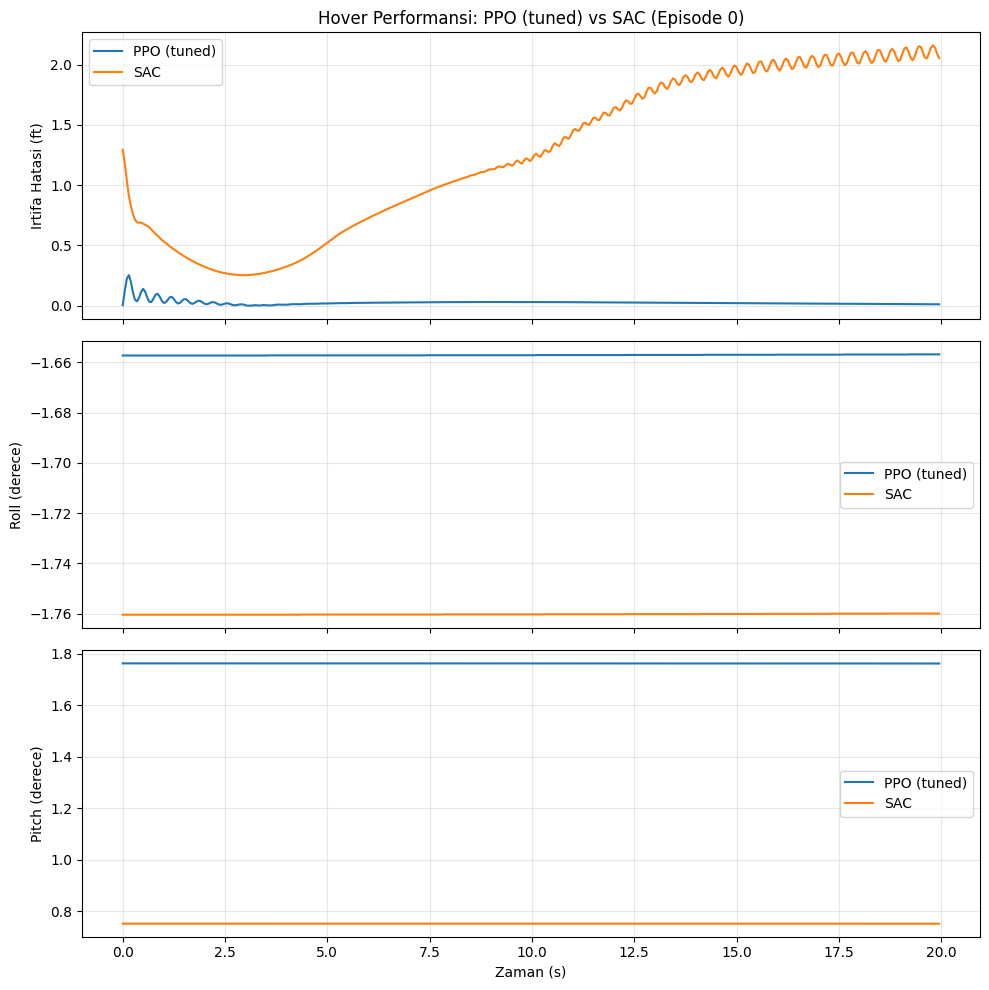

In [160]:
import pandas as pd
tuned_df = pd.read_csv('/content/ppo_telemetry.csv')
print("PPO (tuned) — ort. alt_err_ft:", tuned_df['alt_err_ft'].mean(), "| crashed:", tuned_df['crashed'].any())

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

ppo_df = pd.read_csv('/content/ppo_telemetry.csv')   # bu artik PPO (tuned)
sac_df = pd.read_csv('/content/sac_telemetry.csv')    # SAC (varsayilan)

# Sadece ilk episode'u cizelim, karisik gorunmesin diye
ppo_ep0 = ppo_df[ppo_df['episode'] == 0].reset_index(drop=True)
sac_ep0 = sac_df[sac_df['episode'] == 0].reset_index(drop=True)

fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

# 1. Irtifa hatasi
axes[0].plot(ppo_ep0['timestamp'], ppo_ep0['alt_err_ft'], label='PPO (tuned)', color='tab:blue')
axes[0].plot(sac_ep0['timestamp'], sac_ep0['alt_err_ft'], label='SAC', color='tab:orange')
axes[0].set_ylabel('Irtifa Hatasi (ft)')
axes[0].set_title('Hover Performansi: PPO (tuned) vs SAC (Episode 0)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2. Roll (derece)
axes[1].plot(ppo_ep0['timestamp'], np.degrees(ppo_ep0['roll_rad']), label='PPO (tuned)', color='tab:blue')
axes[1].plot(sac_ep0['timestamp'], np.degrees(sac_ep0['roll_rad']), label='SAC', color='tab:orange')
axes[1].set_ylabel('Roll (derece)')
axes[1].legend()
axes[1].grid(alpha=0.3)

# 3. Pitch (derece)
axes[2].plot(ppo_ep0['timestamp'], np.degrees(ppo_ep0['pitch_rad']), label='PPO (tuned)', color='tab:blue')
axes[2].plot(sac_ep0['timestamp'], np.degrees(sac_ep0['pitch_rad']), label='SAC', color='tab:orange')
axes[2].set_ylabel('Pitch (derece)')
axes[2].set_xlabel('Zaman (s)')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/ppo_vs_sac_comparison.png', dpi=150)
plt.show()
